In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
# XGBoost
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load Dataset

# Dataset path
dataset_path = r"C:\Users\User\Desktop\Machine_Learning_Project\archive (3)\Drug.csv"

# Read CSV file
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(200, 7)


In [7]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Age', 'Sex', 'BP', 'Cholesterol', 'Na', 'K', 'Drug']


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na           200 non-null    float64
 5   K            200 non-null    float64
 6   Drug         200 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 11.1+ KB


In [5]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Age,Na,K
count,200.000000,200.000000,200.000000
mean,44.315000,0.697095,0.050174
std,16.544315,0.118907,0.017611
min,15.000000,0.500169,0.020022
25%,31.000000,0.583887,0.035054
50%,45.000000,0.721853,0.049663
75%,58.000000,0.801494,0.066000
max,74.000000,0.896056,0.079788


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age            0
Sex            0
BP             0
Cholesterol    0
Na             0
K              0
Drug           0
dtype: int64


In [9]:
print("Random Sample Records:")
df.sample(5, random_state=42)

Random Sample Records:


,Age,Sex,BP,Cholesterol,Na,K,Drug
95,36,M,LOW,NORMAL,0.527650,0.046188,drugX
15,16,F,HIGH,NORMAL,0.833837,0.053742,drugY
30,18,F,NORMAL,NORMAL,0.553567,0.063265,drugX
158,59,F,LOW,HIGH,0.640455,0.061320,drugC
128,47,M,LOW,NORMAL,0.847730,0.025274,drugY


In [10]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully.")
    print("New dataset shape:", df.shape)
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


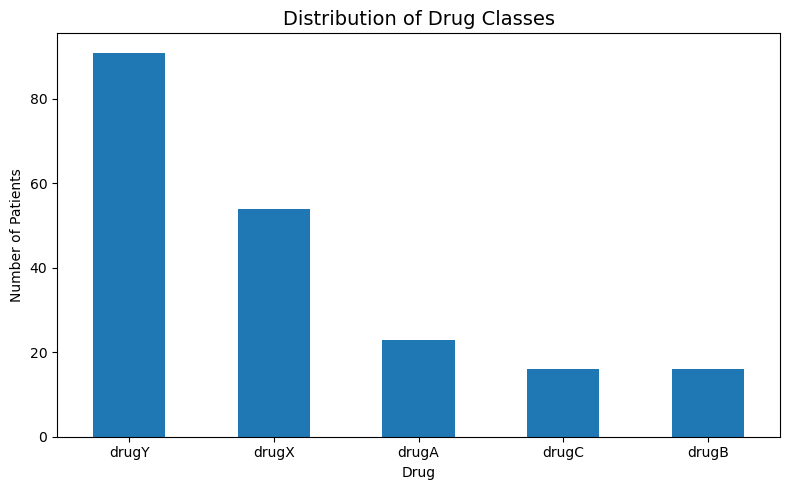

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [74]:
# 3.4 Drug Class Distribution

drug_counts = df['Drug'].value_counts()

plt.figure(figsize=(8,5))
drug_counts.plot(kind='bar')

plt.title("Distribution of Drug Classes", fontsize=14)
plt.xlabel("Drug")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('drug_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(drug_counts)

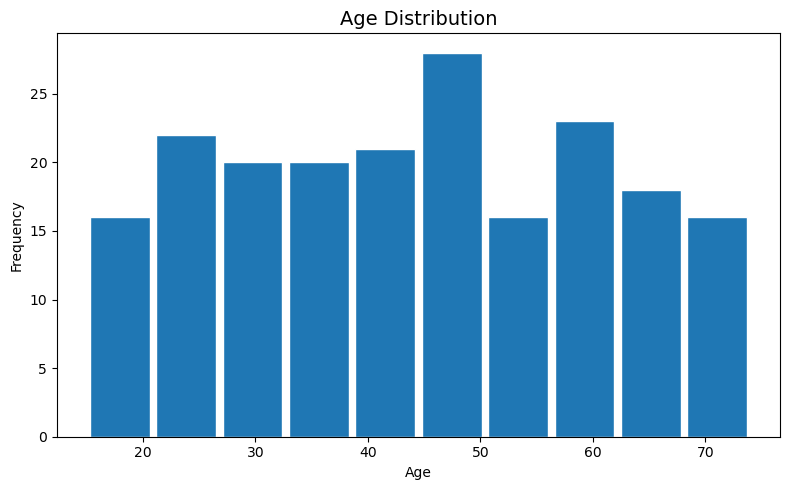

In [49]:
# Age Distribution

plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=10, rwidth=0.9, edgecolor='white')

plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

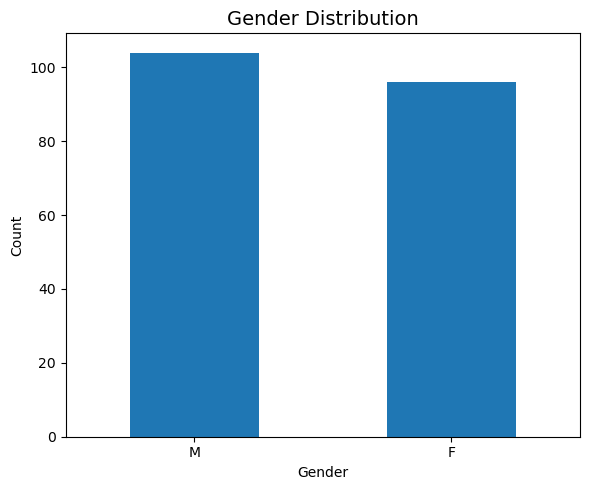

Sex
M    104
F     96
Name: count, dtype: int64


In [13]:
# Gender Distribution
gender_counts = df['Sex'].value_counts()

plt.figure(figsize=(6,5))
gender_counts.plot(kind='bar')

plt.title("Gender Distribution", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(gender_counts)

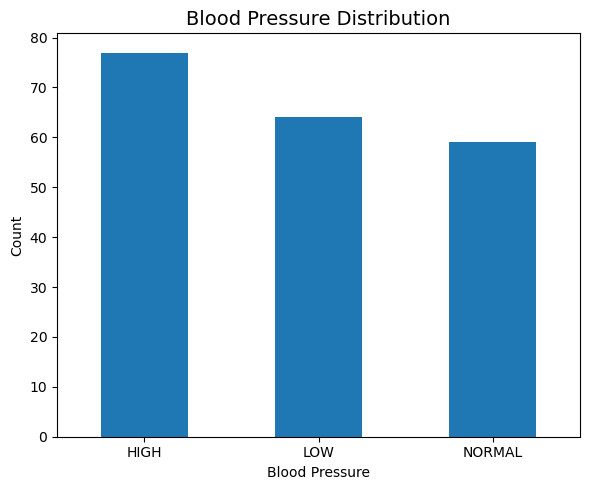

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64


In [14]:
# Blood Pressure Distribution

bp_counts = df['BP'].value_counts()

plt.figure(figsize=(6,5))
bp_counts.plot(kind='bar')

plt.title("Blood Pressure Distribution", fontsize=14)
plt.xlabel("Blood Pressure")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(bp_counts)

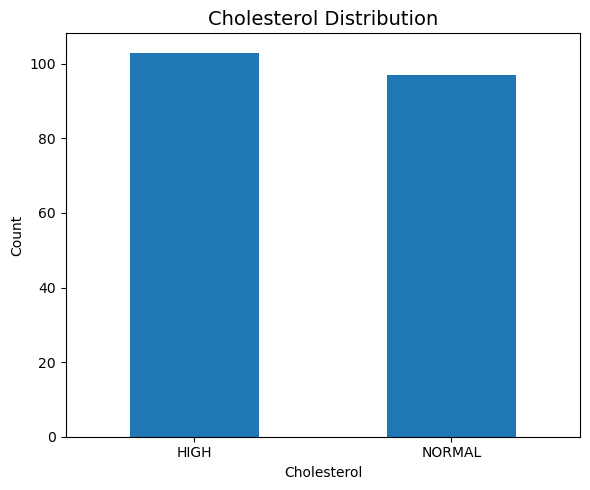

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64


In [15]:
# Cholesterol Distribution

chol_counts = df['Cholesterol'].value_counts()

plt.figure(figsize=(6,5))
chol_counts.plot(kind='bar')

plt.title("Cholesterol Distribution", fontsize=14)
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(chol_counts)

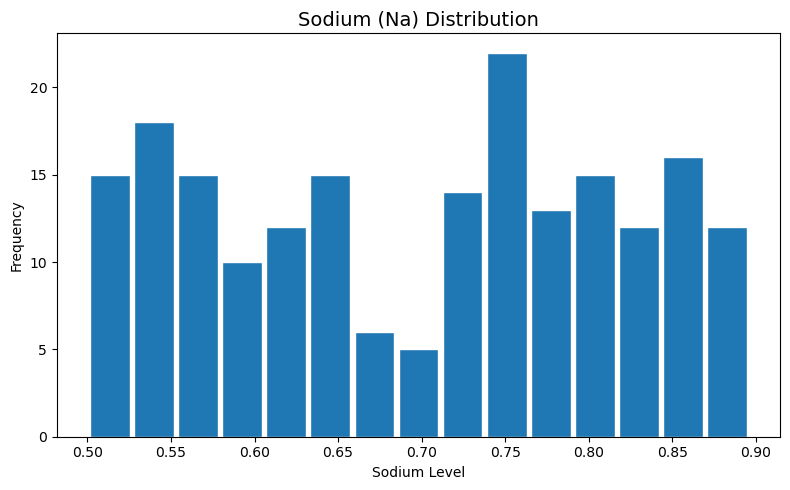

In [50]:
# Sodium (Na) Distribution

plt.figure(figsize=(8,5))

plt.hist(df['Na'], bins=15,rwidth=0.9, edgecolor='white')

plt.title("Sodium (Na) Distribution", fontsize=14)
plt.xlabel("Sodium Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

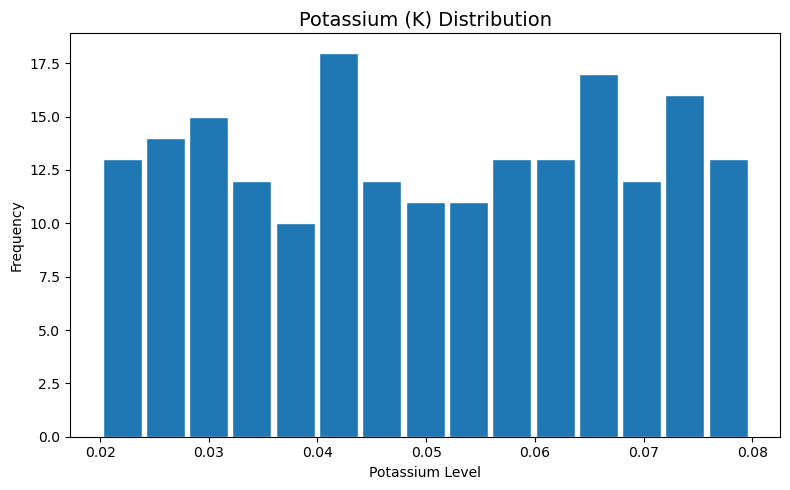

In [51]:
# Potassium (K) Distribution

plt.figure(figsize=(8,5))

plt.hist(df['K'], bins=15,rwidth=0.9, edgecolor='white')

plt.title("Potassium (K) Distribution", fontsize=14)
plt.xlabel("Potassium Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

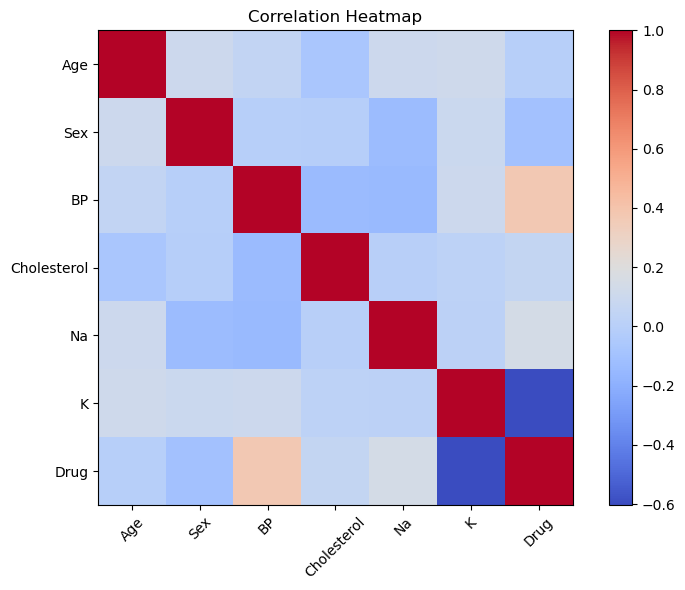

,Age,Sex,BP,Cholesterol,Na,K,Drug
Age,1.000000,0.102027,0.054212,-0.068234,0.100371,0.111491,-0.004828
Sex,0.102027,1.000000,-0.007814,-0.008811,-0.129037,0.092881,-0.098573
BP,0.054212,-0.007814,1.000000,-0.137552,-0.143744,0.100480,0.372868
Cholesterol,-0.068234,-0.008811,-0.137552,1.000000,0.002073,0.024867,0.055629
Na,0.100371,-0.129037,-0.143744,0.002073,1.000000,0.017335,0.148332
K,0.111491,0.092881,0.100480,0.024867,0.017335,1.000000,-0.603014
Drug,-0.004828,-0.098573,0.372868,0.055629,0.148332,-0.603014,1.000000


In [18]:
# Correlation Heatmap
corr_df = df.copy()

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = ['Sex', 'BP', 'Cholesterol', 'Drug']

for col in categorical_cols:
    corr_df[col] = encoder.fit_transform(corr_df[col])

corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

corr_matrix

<h1>Data Preprocessing</h1>

In [19]:
# Input features
X = df.drop('Drug', axis=1)

# Target variable
y = df['Drug']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature Matrix Shape: (200, 6)
Target Shape: (200,)

Features:
   Age Sex      BP Cholesterol        Na         K
0   23   F    HIGH        HIGH  0.792535  0.031258
1   47   M     LOW        HIGH  0.739309  0.056468
2   47   M     LOW        HIGH  0.697269  0.068944
3   28   F  NORMAL        HIGH  0.563682  0.072289
4   61   F     LOW        HIGH  0.559294  0.030998

Target:
0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object


In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
target_encoder = LabelEncoder()

# Encode target variable
y = target_encoder.fit_transform(y)

print("Encoded Target Labels:")
print(y[:10])

print("\nLabel Mapping:")
for index, label in enumerate(target_encoder.classes_):
    print(f"{label} --> {index}")

Encoded Target Labels:
[4 2 2 3 4 3 4 2 4 4]

Label Mapping:
drugA --> 0
drugB --> 1
drugC --> 2
drugX --> 3
drugY --> 4


In [21]:
# One-Hot Encode categorical features
X = pd.get_dummies(
    X,
    columns=['Sex', 'BP', 'Cholesterol'],
    drop_first=False
)

print("Encoded Feature Matrix:")
print(X.head())

Encoded Feature Matrix:
   Age        Na         K  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  Cholesterol_HIGH  Cholesterol_NORMAL
0   23  0.792535  0.031258   True  False     True   False      False              True               False
1   47  0.739309  0.056468  False   True    False    True      False              True               False
2   47  0.697269  0.068944  False   True    False    True      False              True               False
3   28  0.563682  0.072289   True  False    False   False       True              True               False
4   61  0.559294  0.030998   True  False    False    True      False              True               False


In [22]:
print(X.dtypes)

Age                     int64
Na                    float64
K                     float64
Sex_F                    bool
Sex_M                    bool
BP_HIGH                  bool
BP_LOW                   bool
BP_NORMAL                bool
Cholesterol_HIGH         bool
Cholesterol_NORMAL       bool
dtype: object


In [23]:
# Convert boolean columns to integers
bool_columns = X.select_dtypes(include='bool').columns

X[bool_columns] = X[bool_columns].astype(int)

print(X.dtypes)

Age                     int64
Na                    float64
K                     float64
Sex_F                   int32
Sex_M                   int32
BP_HIGH                 int32
BP_LOW                  int32
BP_NORMAL               int32
Cholesterol_HIGH        int32
Cholesterol_NORMAL      int32
dtype: object


In [24]:
# Final Feature Matrix

print("Final Feature Matrix Shape:", X.shape)

X.head()

Final Feature Matrix Shape: (200, 10)


,Age,Na,K,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,0.792535,0.031258,1,0,1,0,0,1,0
1,47,0.739309,0.056468,0,1,0,1,0,1,0
2,47,0.697269,0.068944,0,1,0,1,0,1,0
3,28,0.563682,0.072289,1,0,0,0,1,1,0
4,61,0.559294,0.030998,1,0,0,1,0,1,0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
X_train
X_test
y_train
y_test

X_train_scaled
X_test_scaled

array([[ 0.13406695, -1.37590038,  0.1626851 ,  1.01257911, -1.01257911,
        -0.77459667,  1.46193533, -0.6644106 ,  0.97530483, -0.97530483],
       [ 0.25225269, -0.6371357 ,  0.3487178 , -0.98757716,  0.98757716,
        -0.77459667,  1.46193533, -0.6644106 , -1.02532046,  1.02532046],
       [ 0.31134556, -1.56025055,  1.06576714, -0.98757716,  0.98757716,
         1.29099445, -0.68402479, -0.6644106 ,  0.97530483, -0.97530483],
       [-0.7523261 , -1.29353518,  1.31402336,  1.01257911, -1.01257911,
        -0.77459667, -0.68402479,  1.50509339,  0.97530483, -0.97530483],
       [-0.27958314, -1.22698073, -1.78567105, -0.98757716,  0.98757716,
         1.29099445, -0.68402479, -0.6644106 ,  0.97530483, -0.97530483],
       [ 1.07955287, -0.72096788, -1.56814965, -0.98757716,  0.98757716,
        -0.77459667, -0.68402479,  1.50509339,  0.97530483, -0.97530483],
       [ 0.07497408,  0.62978376, -1.65345329,  1.01257911, -1.01257911,
         1.29099445, -0.68402479, -0.6644106 

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='mlogloss'
        )
}

In [30]:
# Train All Models
trained_models = {}

predictions = {}

probabilities = {}

for name, model in models.items():

    print("="*60)
    print(f"Training {name}...")
    
    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)

    trained_models[name] = model

    predictions[name] = y_pred

    probabilities[name] = y_prob

    print(f"{name} training completed.")

Training Logistic Regression...
Logistic Regression training completed.
Training Decision Tree...
Decision Tree training completed.
Training Random Forest...
Random Forest training completed.
Training KNN...
KNN training completed.
Training SVM...
SVM training completed.
Training Gradient Boosting...
Gradient Boosting training completed.
Training XGBoost...
XGBoost training completed.


In [37]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [38]:
# Evaluate All Models
results = []

for model_name in predictions.keys():

    y_pred = predictions[model_name]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.950,0.980000,0.963636,0.969474
1,Random Forest,0.850,0.916522,0.772121,0.824031
2,SVM,0.850,0.914545,0.827677,0.858421
3,XGBoost,0.825,0.688571,0.664040,0.668272
4,Decision Tree,0.800,0.791622,0.708485,0.709657
5,Gradient Boosting,0.800,0.601754,0.652929,0.619859
6,KNN,0.725,0.743001,0.779192,0.748755


In [40]:
# Best performing model
best_model = results_df.iloc[0]

print("="*50)
print("Best Performing Model")
print("="*50)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")

Best Performing Model
Model      : Logistic Regression
Accuracy   : 0.9500
Precision  : 0.9800
Recall     : 0.9636
F1 Score   : 0.9695


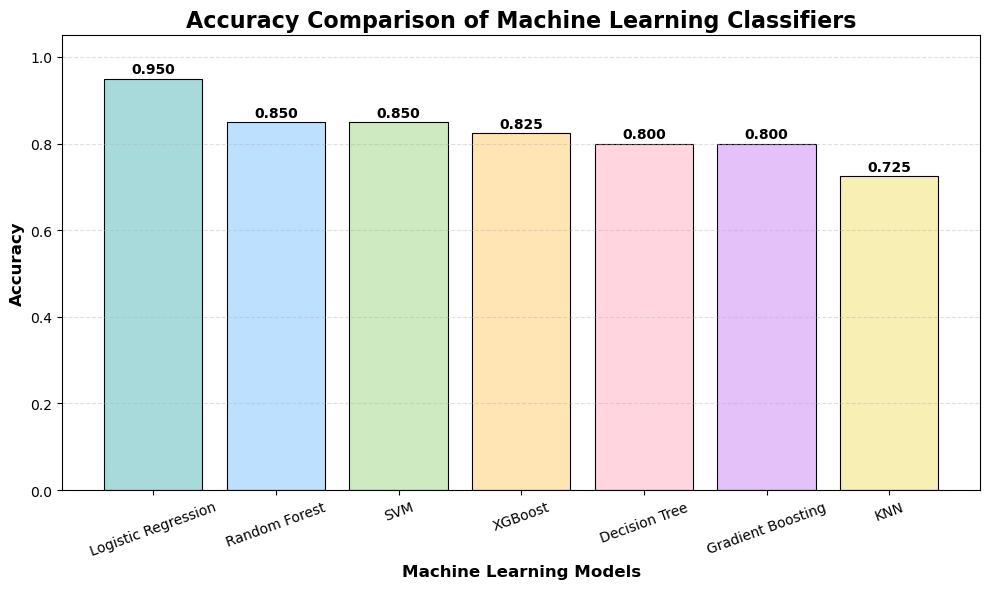

In [52]:
# Model Accuracy Comparison

import matplotlib.pyplot as plt
results_plot = results_df.sort_values(by='Accuracy', ascending=False)
colors = [
    '#A8DADC',  # Light Cyan
    '#BDE0FE',  # Light Blue
    '#CDEAC0',  # Light Green
    '#FFE5B4',  # Light Orange
    '#FFD6E0',  # Light Pink
    '#E4C1F9',  # Light Purple
    '#F8EFB4'   # Light Yellow
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    results_plot['Model'],
    results_plot['Accuracy'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Accuracy Comparison of Machine Learning Classifiers',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Machine Learning Models',
           fontsize=12,
           fontweight='bold')

plt.ylabel('Accuracy',
           fontsize=12,
           fontweight='bold')

plt.ylim(0, 1.05)

plt.xticks(rotation=20, fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("Model_Accuracy_Comparison.png", dpi=300, bbox_inches='tight')

plt.show()

In [42]:
# Classification Report for All Models

from sklearn.metrics import classification_report

for model_name in predictions.keys():

    print("="*70)
    print(f"Classification Report - {model_name}")
    print("="*70)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=target_encoder.classes_
        )
    )

Classification Report - Logistic Regression
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.82      0.90        11
       drugY       0.90      1.00      0.95        18

    accuracy                           0.95        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.96      0.95      0.95        40

Classification Report - Decision Tree
              precision    recall  f1-score   support

       drugA       0.50      0.80      0.62         5
       drugB       1.00      0.33      0.50         3
       drugC       0.67      0.67      0.67         3
       drugX       0.91      0.91      0.91        11
       drugY       0.88      0.83      0.86        18

    accuracy                           0.80        40
   macro avg       0.79      0.71      0.71      

<Figure size 600x500 with 0 Axes>

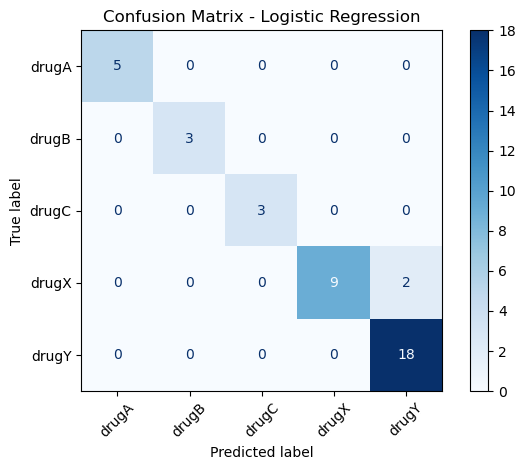

<Figure size 600x500 with 0 Axes>

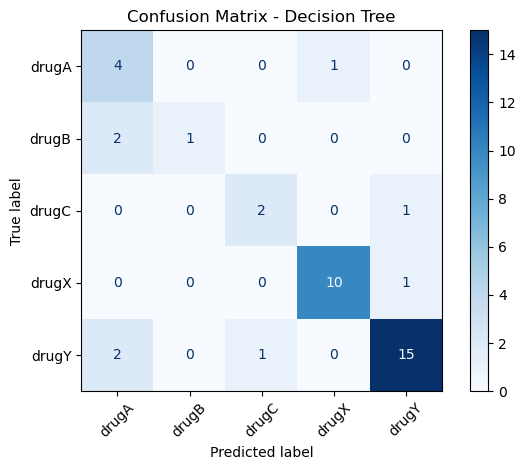

<Figure size 600x500 with 0 Axes>

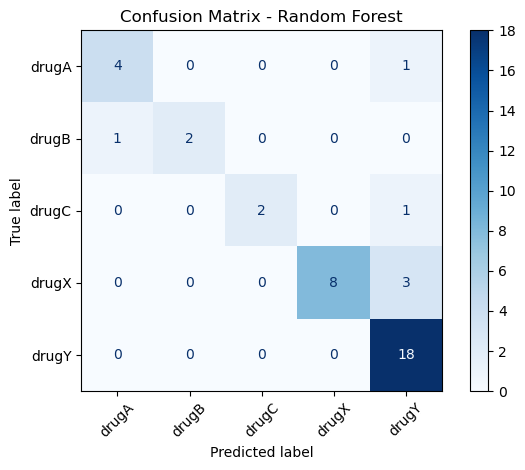

<Figure size 600x500 with 0 Axes>

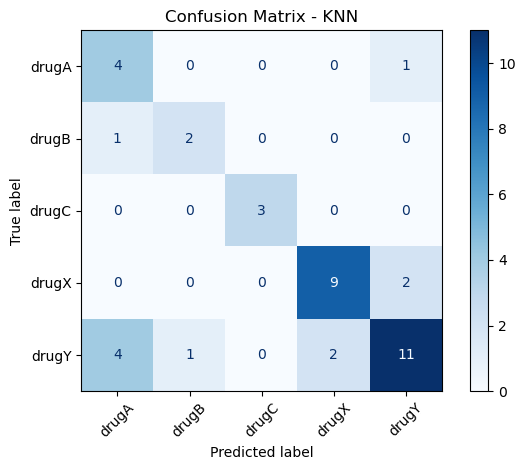

<Figure size 600x500 with 0 Axes>

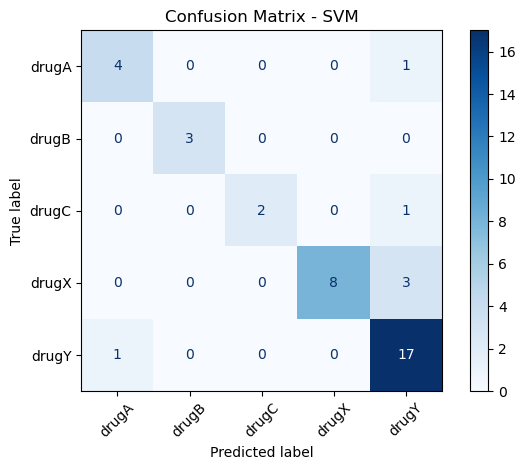

<Figure size 600x500 with 0 Axes>

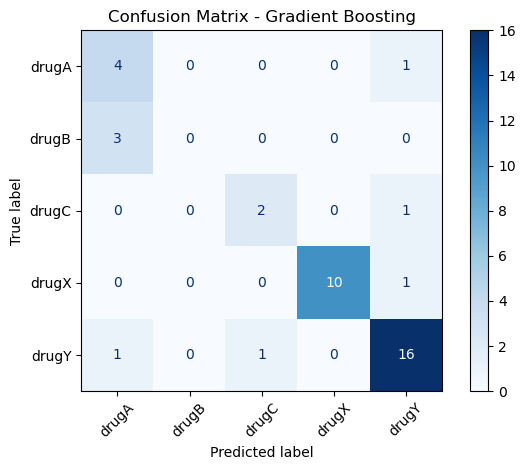

<Figure size 600x500 with 0 Axes>

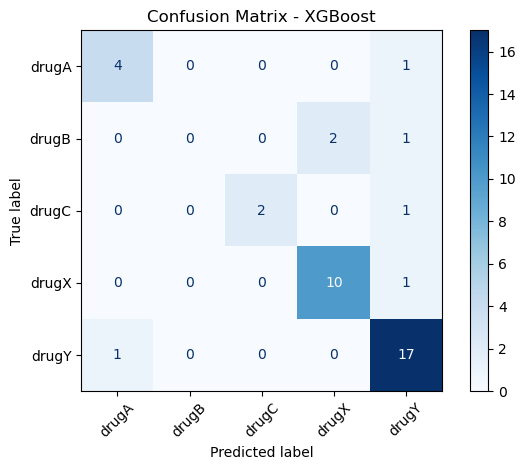

In [43]:
# Confusion Matrix for All Models

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name in predictions.keys():

    plt.figure(figsize=(6,5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name],
        display_labels=target_encoder.classes_,
        cmap='Blues',
        xticks_rotation=45
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name}.png", dpi=300)

    plt.show()

In [44]:
# ROC Curves

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels
classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_test_bin.shape[1]

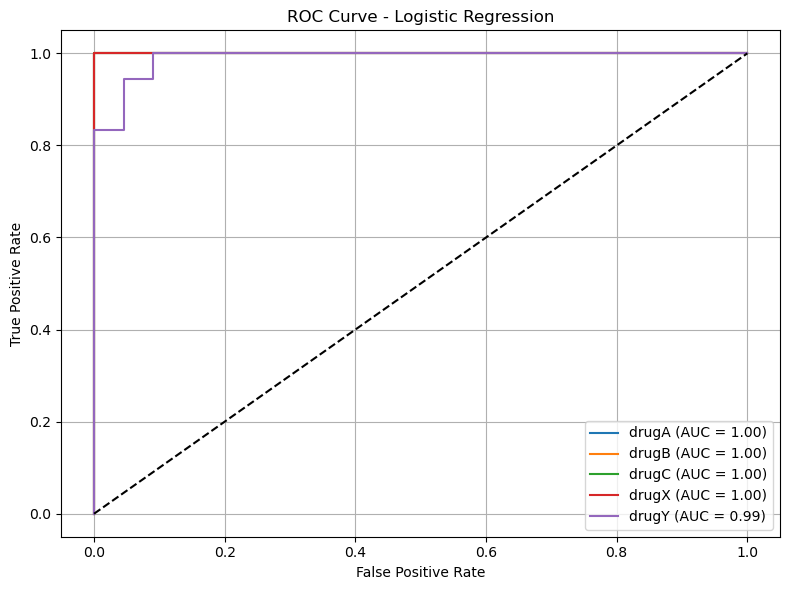

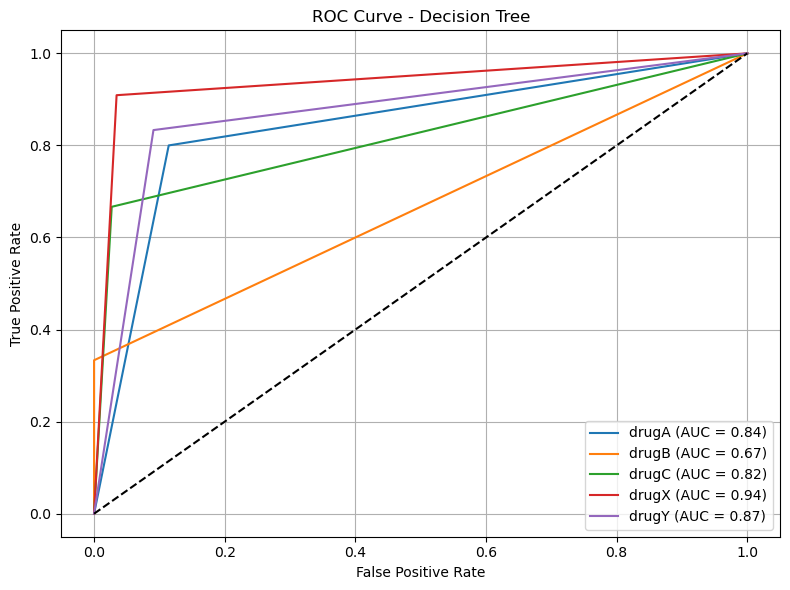

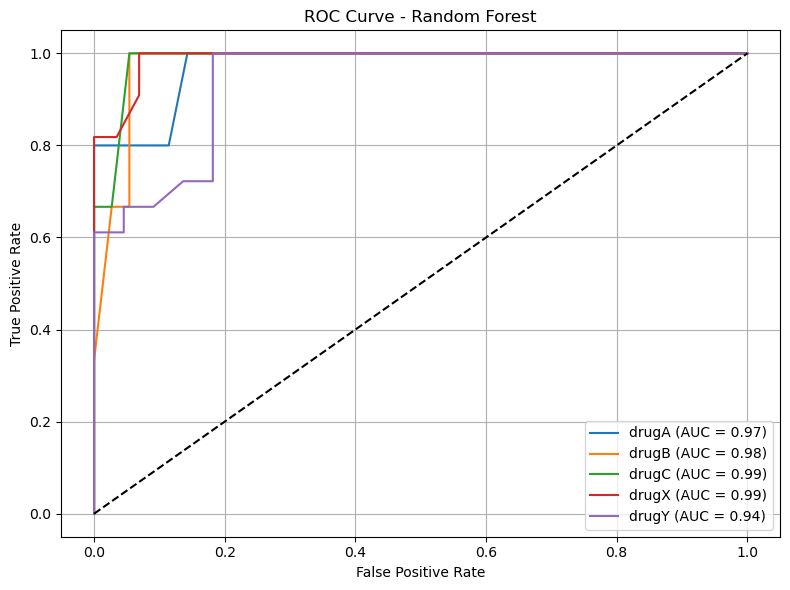

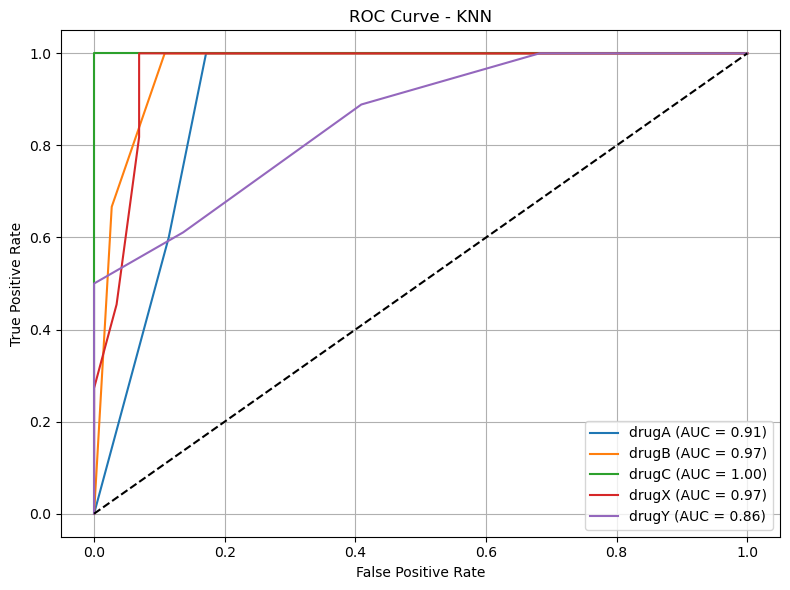

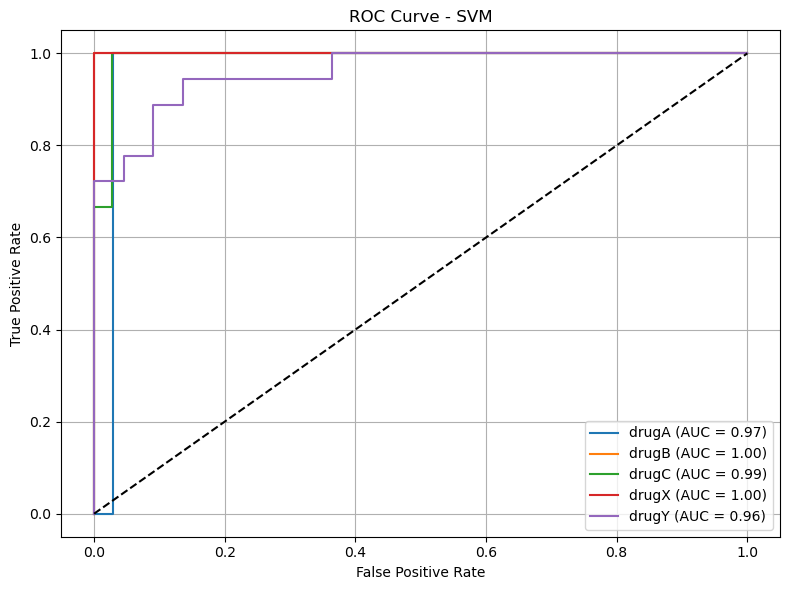

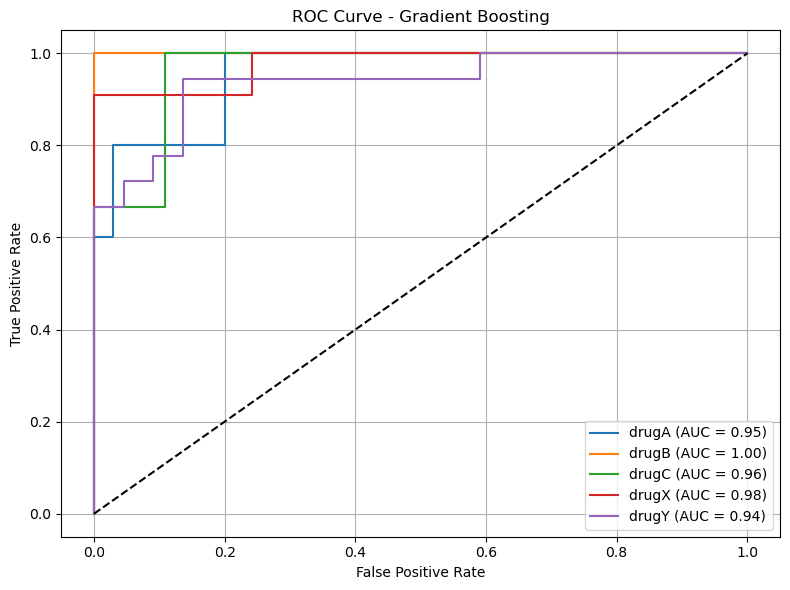

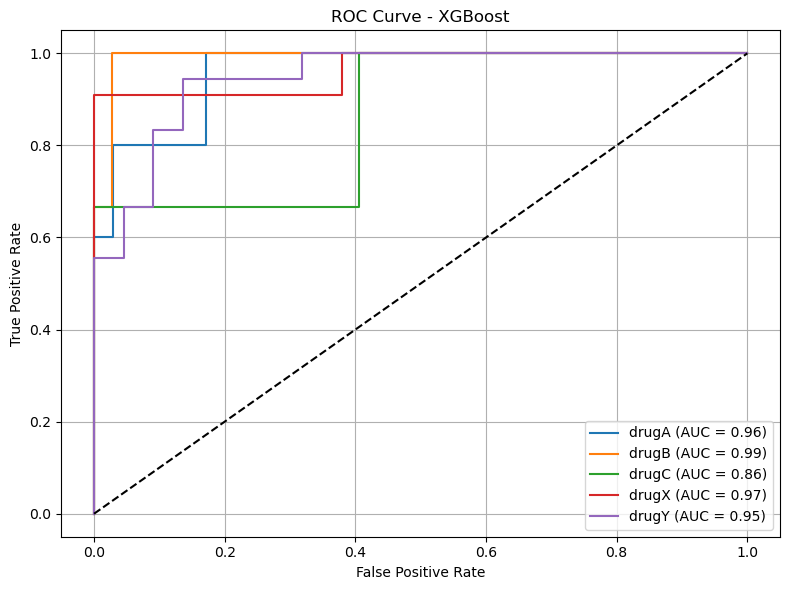

In [45]:
# ROC Curves

for model_name in probabilities.keys():

    plt.figure(figsize=(8,6))

    y_score = probabilities[model_name]

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'{target_encoder.classes_[i]} (AUC = {roc_auc:.2f})'
        )

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(f"ROC_{model_name}.png", dpi=300)

    plt.show()

In [47]:
from sklearn.model_selection import cross_val_score
# 5-Fold Cross Validation

cv_results = []

for model_name, model in models.items():

    if model_name in [
        'Logistic Regression',
        'KNN',
        'Support Vector Machine'
    ]:

        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring='accuracy'
        )

    else:

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring='accuracy'
        )

    cv_results.append({

        "Model": model_name,

        "Mean Accuracy": scores.mean(),

        "Standard Deviation": scores.std()

    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean Accuracy",
    ascending=False
)

cv_results_df.reset_index(drop=True, inplace=True)

cv_results_df

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.95000,0.037500
1,XGBoost,0.95000,0.025000
2,Random Forest,0.93750,0.027951
3,Gradient Boosting,0.93125,0.012500
4,Decision Tree,0.87500,0.019764
5,KNN,0.72500,0.072349
6,SVM,0.45625,0.015309


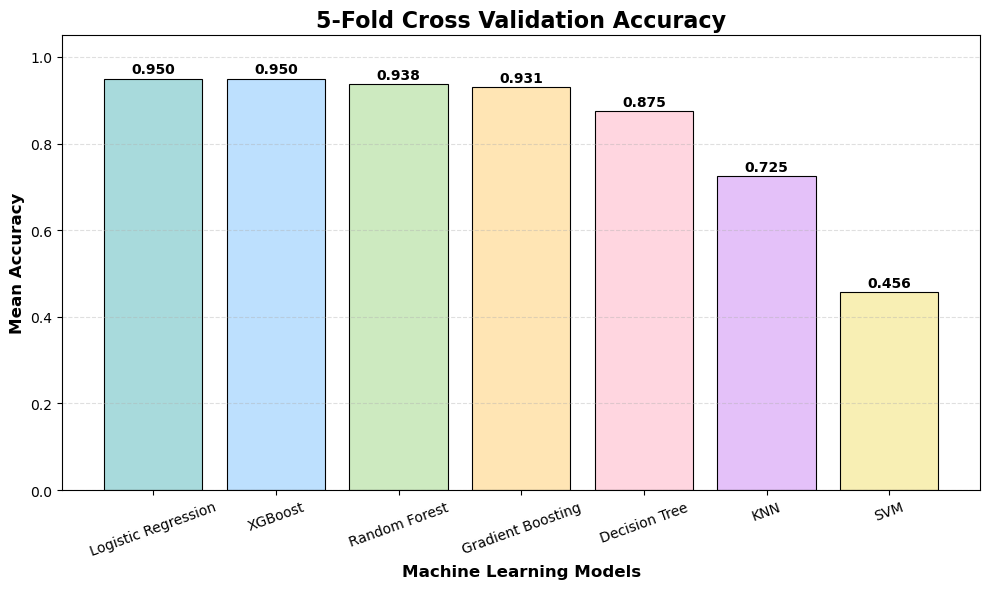

In [53]:
# 5-Fold Cross Validation Accuracy Comparison

import matplotlib.pyplot as plt
colors = [
    '#A8DADC',  # Light Cyan
    '#BDE0FE',  # Light Blue
    '#CDEAC0',  # Light Green
    '#FFE5B4',  # Light Orange
    '#FFD6E0',  # Light Pink
    '#E4C1F9',  # Light Purple
    '#F8EFB4'   # Light Yellow
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean Accuracy"],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "5-Fold Cross Validation Accuracy",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Mean Accuracy",
    fontsize=12,
    fontweight='bold'
)

plt.ylim(0, 1.05)

plt.xticks(rotation=20, fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Cross_Validation_Accuracy.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [54]:
# XGBoost Feature Importance

import pandas as pd

# Get the trained XGBoost model
xgb_model = models['XGBoost']

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.reset_index(drop=True, inplace=True)

feature_importance

,Feature,Importance
0,BP_HIGH,0.306806
1,K,0.178112
2,BP_LOW,0.152265
3,BP_NORMAL,0.130940
4,Cholesterol_HIGH,0.100446
5,Na,0.069740
6,Age,0.061619
7,Sex_F,0.000072
8,Sex_M,0.000000
9,Cholesterol_NORMAL,0.000000


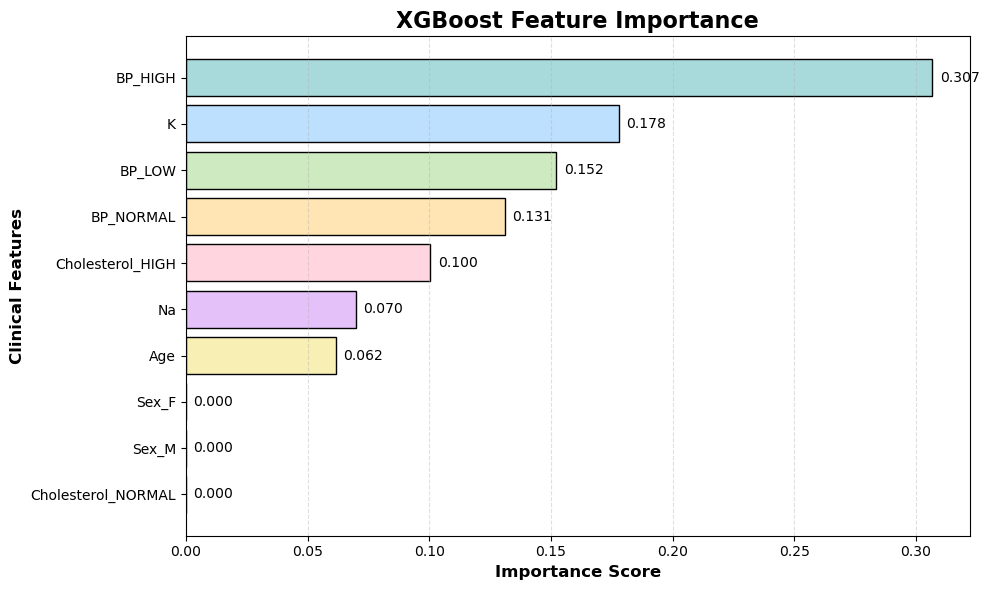

In [55]:
# XGBoost Feature Importance Plot

import matplotlib.pyplot as plt

colors = [
    '#A8DADC',
    '#BDE0FE',
    '#CDEAC0',
    '#FFE5B4',
    '#FFD6E0',
    '#E4C1F9',
    '#F8EFB4',
    '#C7F9CC',
    '#FFDAB9',
    '#D8BFD8'
]

plt.figure(figsize=(10,6))

bars = plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color=colors[:len(feature_importance)],
    edgecolor='black'
)

# Highest importance on top
plt.gca().invert_yaxis()

# Add values
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=10
    )

plt.title(
    "XGBoost Feature Importance",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Importance Score",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Clinical Features",
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "XGBoost_Feature_Importance.png",
    dpi=300
)

plt.show()

In [70]:
# ==========================================
# Logistic Regression Feature Importance
# ==========================================

import pandas as pd
import numpy as np

# Get trained Logistic Regression model
lr_model = models['Logistic Regression']

# Compute mean absolute coefficient across all classes
importance = np.mean(np.abs(lr_model.coef_), axis=0)

# Create DataFrame
lr_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort by importance
lr_feature_importance = lr_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

lr_feature_importance.reset_index(drop=True, inplace=True)

# Display feature importance
lr_feature_importance

,Feature,Importance
0,K,1.401884
1,BP_HIGH,0.918678
2,BP_NORMAL,0.683750
3,Na,0.632973
4,Age,0.613646
5,BP_LOW,0.584909
6,Cholesterol_HIGH,0.371188
7,Cholesterol_NORMAL,0.371188
8,Sex_F,0.072729
9,Sex_M,0.072729


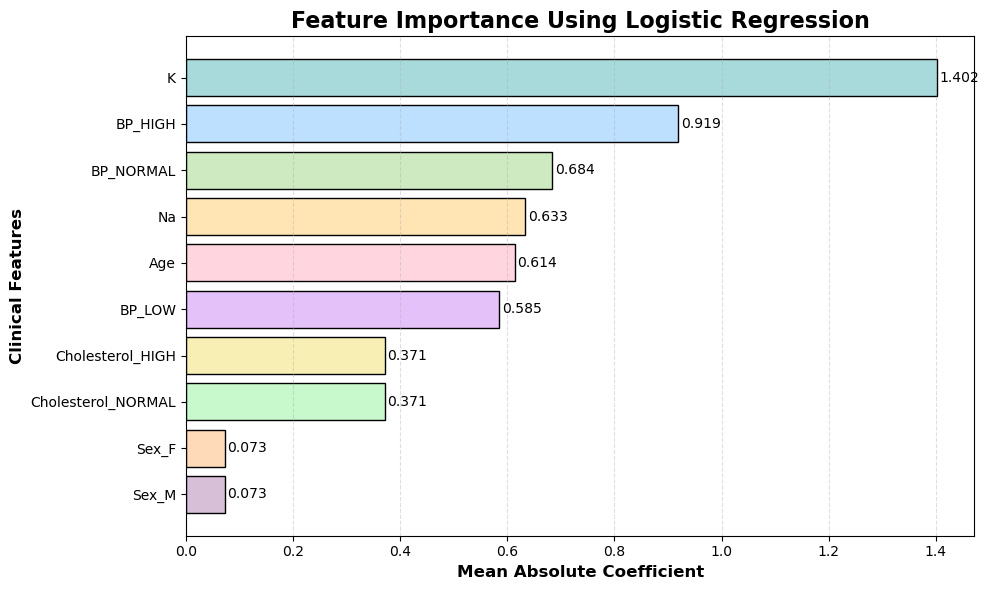

In [71]:
# ==========================================
# Logistic Regression Feature Importance Plot
# ==========================================

import matplotlib.pyplot as plt

colors = [
    '#A8DADC',
    '#BDE0FE',
    '#CDEAC0',
    '#FFE5B4',
    '#FFD6E0',
    '#E4C1F9',
    '#F8EFB4',
    '#C7F9CC',
    '#FFDAB9',
    '#D8BFD8'
]

plt.figure(figsize=(10,6))

bars = plt.barh(
    lr_feature_importance['Feature'],
    lr_feature_importance['Importance'],
    color=colors[:len(lr_feature_importance)],
    edgecolor='black'
)

# Show most important feature at the top
plt.gca().invert_yaxis()

# Display importance values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=10
    )

plt.title(
    "Feature Importance Using Logistic Regression",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Mean Absolute Coefficient",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Clinical Features",
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Logistic_Regression_Feature_Importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [72]:
# Drug Recommendation Comparison

# Logistic Regression predictions
lr_pred = models['Logistic Regression'].predict(X_test_scaled)

# XGBoost predictions
xgb_pred = models['XGBoost'].predict(X_test)

# Decode labels
lr_drug = target_encoder.inverse_transform(lr_pred)
xgb_drug = target_encoder.inverse_transform(xgb_pred)
actual_drug = target_encoder.inverse_transform(y_test)

# Original patient information
comparison_df = df.loc[X_test.index].copy()

comparison_df = comparison_df[
    ['Age', 'Sex', 'BP', 'Cholesterol', 'Na', 'K']
]

comparison_df['Actual Drug'] = actual_drug
comparison_df['Logistic Regression'] = lr_drug
comparison_df['XGBoost'] = xgb_drug

comparison_df.head(20)

,Age,Sex,BP,Cholesterol,Na,K,Actual Drug,Logistic Regression,XGBoost
84,47,F,LOW,HIGH,0.539774,0.053620,drugC,drugC,drugC
32,49,M,LOW,NORMAL,0.625889,0.056828,drugX,drugX,drugX
110,50,M,HIGH,HIGH,0.518285,0.069193,drugA,drugA,drugA
129,32,F,NORMAL,HIGH,0.549375,0.073474,drugX,drugX,drugX
57,40,M,HIGH,HIGH,0.557133,0.020022,drugY,drugY,drugY
21,63,M,NORMAL,HIGH,0.616117,0.023773,drugY,drugY,drugY
194,46,F,HIGH,HIGH,0.773569,0.022302,drugY,drugY,drugY
96,58,F,LOW,HIGH,0.886865,0.023188,drugY,drugY,drugY
74,31,M,HIGH,NORMAL,0.886240,0.051922,drugY,drugY,drugY
126,66,M,HIGH,HIGH,0.849850,0.051988,drugY,drugY,drugY


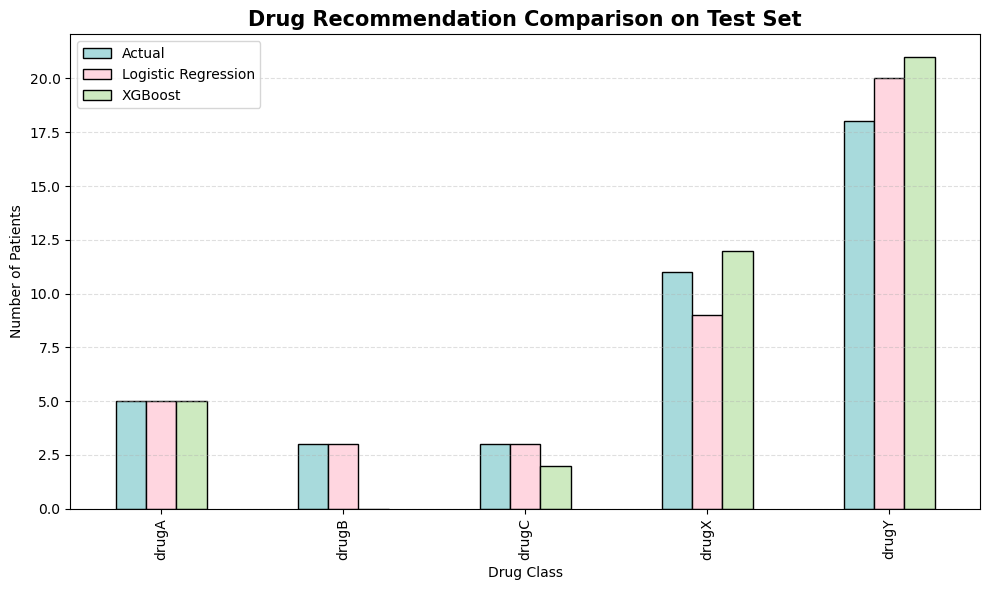

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    'Actual': actual_drug,
    'Logistic Regression': lr_drug,
    'XGBoost': xgb_drug
})

counts = pd.DataFrame({
    'Actual': plot_df['Actual'].value_counts(),
    'Logistic Regression': plot_df['Logistic Regression'].value_counts(),
    'XGBoost': plot_df['XGBoost'].value_counts()
}).fillna(0)

counts = counts.sort_index()

colors = ['#A8DADC', '#FFD6E0', '#CDEAC0']

counts.plot(
    kind='bar',
    figsize=(10,6),
    color=colors,
    edgecolor='black'
)

plt.title(
    'Drug Recommendation Comparison on Test Set',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Drug Class')
plt.ylabel('Number of Patients')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    'Drug_Recommendation_Comparison.png',
    dpi=300
)

plt.show()